In [1]:
!pip install torchsummary

In [2]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler


In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [4]:
# Transformations
transform = transforms.Compose([
    transforms.Resize(224),           # Resize 32x32 → 224x224
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize [-1,1]
])

In [5]:
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            transform=transform, download=True)

100%|██████████| 170M/170M [00:05<00:00, 34.0MB/s]


In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [7]:
# Get one batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

print("Images shape:", images.shape)   # (batch_size, 3, 224, 224)
print("Labels shape:", labels.shape)   # (batch_size,)

Images shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])


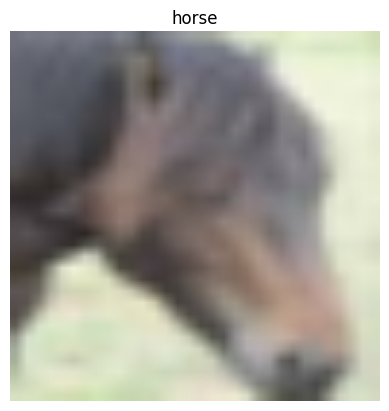

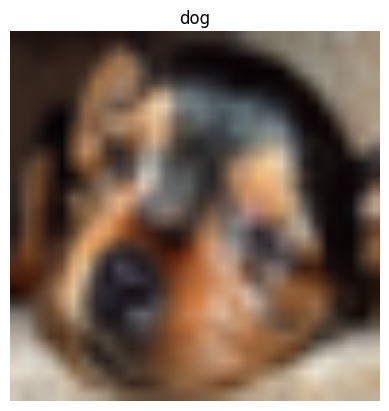

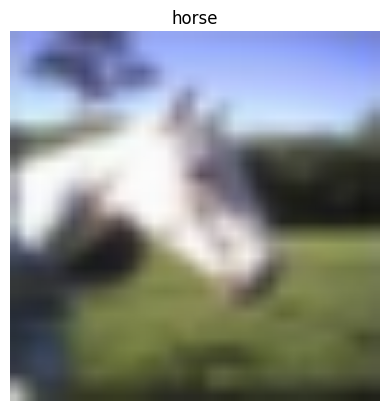

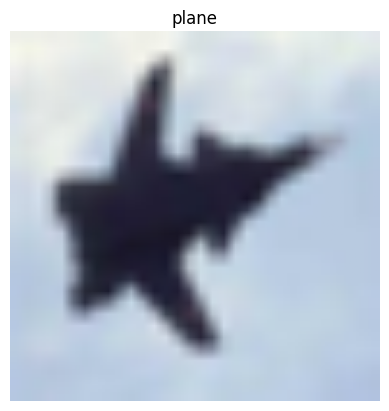

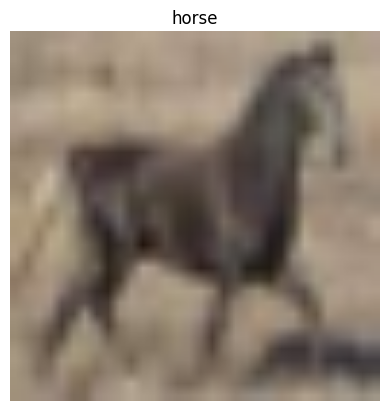

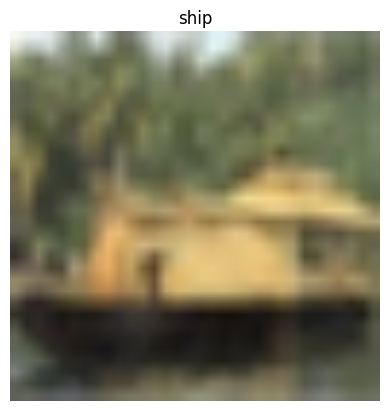

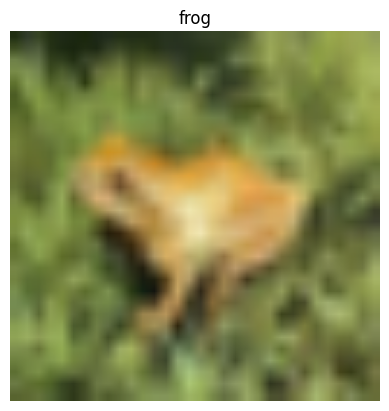

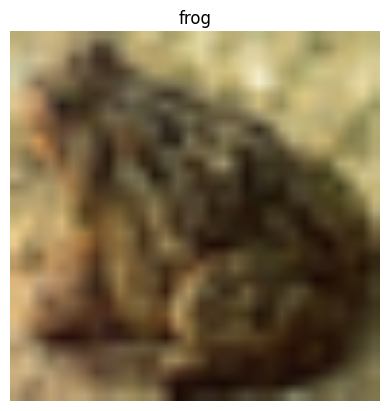

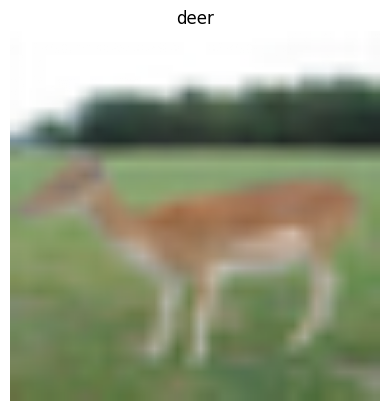

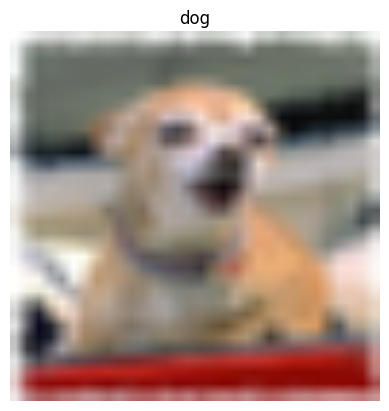

In [8]:
import matplotlib.pyplot as plt

# CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Show 10 images individually with their labels
for i in range(10):
    img = images[i] / 2 + 0.5  # unnormalize [-1,1] → [0,1]
    npimg = img.numpy()
    plt.figure()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(classes[labels[i]])
    plt.axis("off")
    plt.show()

In [9]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(AlexNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(384),
            nn.ReLU())
        self.layer5 = nn.Sequential(
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2))

        # Compute flattened size dynamically
        self._initialize_fc_input()

        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.fc_input_size, 4096),
            nn.ReLU())
        self.fc2 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc3 = nn.Linear(4096, num_classes)

    def _initialize_fc_input(self):
        x = torch.zeros(1, 3, 224, 224)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        self.fc_input_size = x.numel()  # total features
        print("Flattened feature size:", self.fc_input_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

In [10]:
from torchsummary import summary

model = AlexNet(10).to(device)

# Print summary for input shape (3, 224, 224)
summary(model, (3, 224, 224))

Flattened feature size: 6400
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 54, 54]          34,944
       BatchNorm2d-2           [-1, 96, 54, 54]             192
              ReLU-3           [-1, 96, 54, 54]               0
         MaxPool2d-4           [-1, 96, 26, 26]               0
            Conv2d-5          [-1, 256, 26, 26]         614,656
       BatchNorm2d-6          [-1, 256, 26, 26]             512
              ReLU-7          [-1, 256, 26, 26]               0
         MaxPool2d-8          [-1, 256, 12, 12]               0
            Conv2d-9          [-1, 384, 12, 12]         885,120
      BatchNorm2d-10          [-1, 384, 12, 12]             768
             ReLU-11          [-1, 384, 12, 12]               0
           Conv2d-12          [-1, 384, 12, 12]       1,327,488
      BatchNorm2d-13          [-1, 384, 12, 12]             768
          

In [11]:
num_epochs = 80
learning_rate = 0.001

In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9)


# Train the model
total_step = len(train_loader)
print("Total batches per epoch:", total_step)

Total batches per epoch: 782


In [ ]:
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    # Calculate epoch stats
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {running_loss/len(train_loader):.4f}, "
          f"Acc: {100*correct/total:.2f}%")

Epoch [1/80], Loss: 1.4764, Acc: 45.52%
Epoch [2/80], Loss: 1.0293, Acc: 63.17%
Epoch [3/80], Loss: 0.8430, Acc: 70.14%
Epoch [4/80], Loss: 0.7272, Acc: 74.43%
Epoch [5/80], Loss: 0.6462, Acc: 77.41%
Epoch [6/80], Loss: 0.5824, Acc: 79.71%


In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy', color='green')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model.eval()  # evaluation mode
correct, total = 0, 0

all_images = []
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # store for visualization
        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_preds.append(predicted.cpu())

print(f"Test Accuracy: {100*correct/total:.2f}%")

In [ ]:
# Concatenate all batches
all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)

# Show 10 random test samples with predictions
indices = np.random.choice(len(all_images), 10, replace=False)
for i in indices:
    img = all_images[i] / 2 + 0.5  # unnormalize [-1,1] -> [0,1]
    npimg = img.numpy()
    plt.figure()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Predicted: {classes[all_preds[i]]} / True: {classes[all_labels[i]]}")
    plt.axis("off")
    plt.show()